<a href="https://colab.research.google.com/github/emflores-dev/mna-big-data/blob/main/Actividad5_VisualizacionResultados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

# Análisis de Grandes Volúmenes de datos

## Instituto Tecnológico de Monterrey

## Actividad 5: Visualización de Resultados

---

Alumnos:
- **Ángel García Ortega - A01796653**
- **Emanuel Flores Martínez - A01796497**
- **Héctor Magaña - A00823440**
- **José Alberto Rodríguez Sotomayor - A01796604**
---


La Actividad 4 determinó —mediante
ajuste de hiper-parámetros con validación cruzada (`CrossValidator` + `ParamGridBuilder`,
F1 ponderado)— que el algoritmo que **mejor reportó resultados** fue el
**`RandomForestClassifier`** con la configuración **`numTrees = 100`, `maxDepth = 5`**, y
que la **métrica de calidad principal** para esta tarea (clasificación multiclase
desbalanceada de `market_direction`) es el **F1 ponderado**, acompañada de accuracy,
precision/recall ponderados, log-loss, métricas por clase y AUC-ROC/PR *one-vs-rest*.

**Objetivo de la Actividad 5.** *No* re-buscar hiper-parámetros, sino **medir la
variabilidad** de ese mejor modelo mediante un proceso explícito de **validación cruzada
k-fold** y **visualizar** los resultados (dispersión, tendencia central, mapas de calor y
curvas ROC) para juzgar qué tan significativos y estables son.

> **Entorno de ejecución.** El volumen de datos exige ejecutar en la nube (Google Colab
> con los parquet en Drive, Spark 4.0.2). El notebook se ejecutó de extremo a extremo y las
> secciones **4.6** y **5** integran las cifras reales obtenidas en esa corrida.


# 0. Preparación del entorno y reconstrucción de la muestra M

Se reutiliza, sin cambios metodológicos, el flujo de la Actividad 4 hasta obtener la
muestra pre-procesada `M_prep`: carga de los 3 pares, variables derivadas de
caracterización, variables de partición `volatility_level` y `market_period`, tamaño de
muestra por **fórmula de Cochran**, **muestreo aleatorio estratificado proporcional**
(`sampleBy`), limpieza de nulos, casteo y **winsorización** p1/p99. Cada paso queda
documentado en su celda.


In [ ]:
import os, zipfile, fnmatch
from pathlib import Path
from google.colab import drive

drive.mount('/content/drive')

# Kaggle credentials (stored as Colab secrets)
from google.colab import userdata
os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
os.environ["KAGGLE_KEY"]      = userdata.get("KAGGLE_KEY")
!pip install -q kaggle

DATASET     = "jorijnsmit/binance-full-history"
WANTED      = ["BTC", "ETH", "XRP"]                                       # pairs vs USDT

EXTRACT_DIR = Path("/content/drive/MyDrive/binance_full_history/files")   # only 3 parquet, on Drive
TMP_DIR     = Path("/content/_binance_tmp")                               # ephemeral ZIP
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
TMP_DIR.mkdir(parents=True, exist_ok=True)

# 1. If the 3 parquet files already exist on Drive -> nothing to do
existing = sorted(EXTRACT_DIR.glob("*.parquet"))
def _norm(s):
    return ''.join(c for c in s.upper() if c.isalnum())
already = {b for b in WANTED if any(b in _norm(p.stem) and "USDT" in _norm(p.stem) for p in existing)}

if already == set(WANTED):
    print("The 3 parquet files are already on Drive - skipping download.")
    print("Files:", [p.name for p in existing])
else:
    missing = set(WANTED) - already
    print(f"Missing on Drive: {missing}. Downloading ZIP to ephemeral disk...")
    zip_files = list(TMP_DIR.glob("*.zip"))
    if not zip_files:
        get_ipython().system(f'kaggle datasets download -d {DATASET} -p {TMP_DIR}')
        zip_files = list(TMP_DIR.glob("*.zip"))
    ZIP_PATH = zip_files[0]
    print(f"ZIP: {ZIP_PATH}  ({ZIP_PATH.stat().st_size / (1024**3):.2f} GB)")
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        names = z.namelist()
        for base in WANTED:
            matches = [n for n in names if fnmatch.fnmatch(n.upper(), f"*{base}*USDT*.PARQUET")]
            for n in matches:
                dest = EXTRACT_DIR / Path(n).name
                with z.open(n) as src, open(dest, "wb") as out:
                    out.write(src.read())
                print("Extracted to Drive:", dest.name)
    ZIP_PATH.unlink()
    print("Ephemeral ZIP deleted.")

print("\nParquet files available on Drive:", sorted(p.name for p in EXTRACT_DIR.glob("*.parquet")))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
The 3 parquet files are already on Drive - skipping download.
Files: ['BTC-USDT.parquet', 'BTCDOWN-USDT.parquet', 'BTCST-USDT.parquet', 'BTCUP-USDT.parquet', 'ETH-USDT.parquet', 'ETHDOWN-USDT.parquet', 'ETHUP-USDT.parquet', 'XRP-USDT.parquet', 'XRPDOWN-USDT.parquet', 'XRPUP-USDT.parquet']

Parquet files available on Drive: ['BTC-USDT.parquet', 'BTCDOWN-USDT.parquet', 'BTCST-USDT.parquet', 'BTCUP-USDT.parquet', 'ETH-USDT.parquet', 'ETHDOWN-USDT.parquet', 'ETHUP-USDT.parquet', 'XRP-USDT.parquet', 'XRPDOWN-USDT.parquet', 'XRPUP-USDT.parquet']


In [ ]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("Binance ML - Activity 5 Visualization of Results")
    .config("spark.driver.memory", "10g")
    .config("spark.sql.files.maxPartitionBytes", "128MB")
    .config("spark.sql.shuffle.partitions", "64")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")
print("Spark version:", spark.version)


Spark version: 4.0.2


In [ ]:
# Load the 3 pairs, union them and add a 'symbol' column
import glob
from functools import reduce
from pyspark.sql.functions import col, when, hour, year, lit, count, concat_ws

SYMBOLS = ["BTCUSDT", "ETHUSDT", "XRPUSDT"]
all_files = glob.glob(os.path.join(str(EXTRACT_DIR), "*.parquet"))
print(f"Total parquet files available: {len(all_files)}")

def find_pair_file(symbol):
    target = _norm(symbol)
    for f in all_files:
        if _norm(os.path.basename(f).replace('.parquet', '')) == target:
            return f
    return None

pair_files = {sym: find_pair_file(sym) for sym in SYMBOLS}
for sym, f in pair_files.items():
    print(f"{sym:>8} -> {f}")
missing_files = [s for s, f in pair_files.items() if f is None]
assert not missing_files, f"No parquet found for: {missing_files}."

dfs = [spark.read.parquet(pair_files[sym]).withColumn("symbol", lit(sym)) for sym in SYMBOLS]
df3 = reduce(lambda a, b: a.unionByName(b, allowMissingColumns=True), dfs)
print("Columns:", df3.columns)
df3.groupBy("symbol").agg(count("*").alias("rows")).show()


Total parquet files available: 10
 BTCUSDT -> /content/drive/MyDrive/binance_full_history/files/BTC-USDT.parquet
 ETHUSDT -> /content/drive/MyDrive/binance_full_history/files/ETH-USDT.parquet
 XRPUSDT -> /content/drive/MyDrive/binance_full_history/files/XRP-USDT.parquet
Columns: ['open', 'high', 'low', 'close', 'volume', 'quote_asset_volume', 'number_of_trades', 'taker_buy_base_asset_volume', 'taker_buy_quote_asset_volume', 'open_time', 'symbol']
+-------+-------+
| symbol|   rows|
+-------+-------+
|BTCUSDT|2753182|
|ETHUSDT|2753105|
|XRPUSDT|2381218|
+-------+-------+



## 0.1 Variables derivadas de caracterización

Mismas variables derivadas de la Evidencia 1: `return_pct`, `intrabar_volatility_pct`,
`taker_buy_ratio`, `market_direction` (**objetivo supervisado**), `market_session` y
`hour`.


In [ ]:
df_feat = (
    df3
    .filter(col("open").isNotNull() & (col("open") > 0))
    .withColumn("return_pct", (col("close") - col("open")) / col("open") * 100)
    .withColumn("intrabar_volatility_pct", (col("high") - col("low")) / col("open") * 100)
    .withColumn("taker_buy_ratio",
        when(col("volume") > 0, col("taker_buy_base_asset_volume") / col("volume")).otherwise(0.0))
    .withColumn("hour", hour(col("open_time")))
    .withColumn("market_direction",
        when(col("close") > col("open"), "bullish")
        .when(col("close") < col("open"), "bearish")
        .otherwise("neutral"))
    .withColumn("market_session",
        when(col("hour") < 8, "Asia")
        .when(col("hour") < 16, "Europe")
        .otherwise("America"))
)
df_feat.select("symbol", "return_pct", "intrabar_volatility_pct", "taker_buy_ratio",
               "market_direction", "market_session").show(5, truncate=False)


+-------+----------+-----------------------+-------------------+----------------+--------------+
|symbol |return_pct|intrabar_volatility_pct|taker_buy_ratio    |market_direction|market_session|
+-------+----------+-----------------------+-------------------+----------------+--------------+
|BTCUSDT|0.0       |0.0                    |0.04235225229284669|neutral         |Asia          |
|BTCUSDT|0.0       |0.0                    |0.0                |neutral         |Asia          |
|BTCUSDT|0.0       |0.0                    |1.0                |neutral         |Asia          |
|BTCUSDT|0.0       |0.0                    |1.0                |neutral         |Asia          |
|BTCUSDT|0.0       |0.0                    |1.0                |neutral         |Asia          |
+-------+----------+-----------------------+-------------------+----------------+--------------+
only showing top 5 rows


## 0.2 Variables de partición `volatility_level` (B) y `market_period` (C)

`volatility_level` por símbolo con percentiles de `intrabar_volatility_pct`
(LOW ≤ p89, MEDIUM ≤ p99, HIGH > p99) y `market_period` por año
(EARLY < 2020, BULL 2020-2021, MODERN ≥ 2022). Con `symbol` forman las **27 particiones**
`A × B × C`.


In [ ]:
# Per-symbol volatility thresholds + assign volatility_level (B) and market_period (C)
thresholds = {}
for sym in SYMBOLS:
    q = df_feat.filter(col("symbol") == sym).approxQuantile("intrabar_volatility_pct", [0.89, 0.99], 0.001)
    thresholds[sym] = q
    print(f"{sym}: p89={q[0]:.4f}%  p99={q[1]:.4f}%")
thr_df = spark.createDataFrame(
    [(sym, float(thresholds[sym][0]), float(thresholds[sym][1])) for sym in SYMBOLS],
    ["symbol", "p89", "p99"])

df_lvl = (
    df_feat.join(thr_df, on="symbol", how="left")
    .withColumn("volatility_level",
        when(col("intrabar_volatility_pct") <= col("p89"), "LOW")
        .when(col("intrabar_volatility_pct") <= col("p99"), "MEDIUM")
        .otherwise("HIGH"))
    .withColumn("market_period",
        when(year(col("open_time")) < 2020, "EARLY")
        .when(year(col("open_time")) <= 2021, "BULL")
        .otherwise("MODERN"))
    .drop("p89", "p99")
)
df_lvl.groupBy("market_period").agg(count("*").alias("n")).show()


BTCUSDT: p89=0.2630%  p99=0.7346%
ETHUSDT: p89=0.3188%  p99=0.8876%
XRPUSDT: p89=0.3380%  p99=0.9377%
+-------------+-------+
|market_period|      n|
+-------------+-------+
|       MODERN|1382322|
|         BULL|3151164|
|        EARLY|3354019|
+-------------+-------+



## 0.3 Tamaño de muestra (Cochran) y muestreo estratificado proporcional

El tamaño total `n` se fija con la **fórmula de Cochran** para una proporción en población
finita (Z=1.96, p=0.5 escenario de máxima varianza). Se calcula el **mínimo
representativo** `n_min` (con error e=1%) —que será clave para argumentar el valor de `k`
en la sección 1— y se fija el tamaño operativo `TARGET_M`. La muestra se construye con la
**misma fracción para todos los estratos** (asignación proporcional ⇒ *M* reproduce la
distribución de *P* sin sesgo de selección).


In [ ]:
import math

# Stratum key = partition (A x B x C)
df_strat = df_lvl.withColumn(
    "stratum", concat_ws("|", col("symbol"), col("volatility_level"), col("market_period"))
).cache()

N = df_strat.count()
print(f"Population size N (3 pairs): {N:,}")

# --- Cochran's formula -------------------------------------------------------
def cochran_n(N, e, Z=1.96, p=0.5):
    n0 = (Z**2 * p * (1 - p)) / (e**2)
    return n0 / (1 + (n0 - 1) / N)

def effective_error(N, n, Z=1.96, p=0.5):
    fpc = (N - n) / (N - 1)            # finite population correction
    return Z * math.sqrt(p * (1 - p) / n * fpc)

N_MIN = math.ceil(cochran_n(N, 0.01))   # minimum representative size at e = 1%
print(f"Minimum representative sample (95% conf., e=1%): n_min = {N_MIN:,}")


Population size N (3 pairs): 7,887,505
Minimum representative sample (95% conf., e=1%): n_min = 9,593


In [ ]:
# Operating size of M and proportional stratified sampling (same fraction per stratum)
TARGET_M = 70_000
e_eff = effective_error(N, TARGET_M)
print(f"Target operating size for M : {TARGET_M:,}  ->  effective margin of error = {e_eff*100:.3f}%")

FRACTION = min(1.0, TARGET_M / N)
strata = [r["stratum"] for r in df_strat.select("stratum").distinct().collect()]
fractions = {s: FRACTION for s in strata}
print(f"Proportional sampling fraction (all {len(strata)} strata): {FRACTION:.6f}")

M = df_strat.sampleBy("stratum", fractions=fractions, seed=42).cache()
n_M = M.count()
print(f"Sample M size: {n_M:,} instances")


Target operating size for M : 70,000  ->  effective margin of error = 0.369%
Proportional sampling fraction (all 27 strata): 0.008875
Sample M size: 70,304 instances


## 0.4 Limpieza y preparación de M

Diagnóstico/limpieza de nulos, casteo a `double` y **winsorización p1/p99** de las
variables de cola pesada (+ recorte de `return_pct` a ±25 %). Resultado: `M_prep`, lista
para el modelado.


In [ ]:
from pyspark.sql.types import DoubleType

num_cols = ["volume", "quote_asset_volume", "number_of_trades",
            "taker_buy_base_asset_volume", "taker_buy_quote_asset_volume",
            "return_pct", "intrabar_volatility_pct", "taker_buy_ratio"]

M_clean = M.dropna(subset=["close", "open", "volume", "number_of_trades"])
for c in num_cols:
    M_clean = M_clean.withColumn(c, col(c).cast(DoubleType()))

# Outlier treatment (winsorization)
winsor_cols = ["volume", "quote_asset_volume", "number_of_trades",
               "taker_buy_base_asset_volume", "taker_buy_quote_asset_volume"]
M_prep = M_clean
for c in winsor_cols:
    lo, hi = M_clean.approxQuantile(c, [0.01, 0.99], 0.001)
    M_prep = M_prep.withColumn(c, when(col(c) < lo, lo).when(col(c) > hi, hi).otherwise(col(c)))
M_prep = M_prep.withColumn("return_pct",
    when(col("return_pct") > 25, 25.0).when(col("return_pct") < -25, -25.0).otherwise(col("return_pct"))
).cache()

print(f"Pre-processed sample M_prep: {M_prep.count():,} instances")


Pre-processed sample M_prep: 70,304 instances


# 1. Definición del proceso de validación cruzada

## 1.1 Por qué validación cruzada y qué mide aquí

En la Actividad 4 el modelo final se evaluó sobre un **único** *split* 80/20: una sola
estimación de calidad que **no permite cuantificar su variabilidad**. ¿El F1 obtenido fue
producto de esa partición concreta o es estable ante otras? La **validación cruzada
k-fold** responde a esto: se divide *M* en `k` pliegues, se entrena `k` veces (cada vez con
`k-1` pliegues y validando en el restante) y se obtienen **`k` estimaciones independientes**
de cada métrica. Su **media** estima el desempeño esperado y su **desviación estándar mide
la variabilidad** (sensibilidad del resultado a la partición de los datos) — justo lo que
esta actividad pide analizar.

## 1.2 Criterio para elegir k: que cada fold sea muestra representativa de P

El requisito explícito de la actividad es que **cada uno de los `k` folds sea una muestra
representativa de la población**. Ya disponemos de un criterio **cuantitativo** de
representatividad heredado de la Actividad 4: la **fórmula de Cochran**, que fija el tamaño
mínimo `n_min` para que una muestra refleje a *P* con 95 % de confianza y error ≤ 1 %
(sobre `N ≈ 7.9 M`, resulta `n_min ≈ 9,600` instancias).

En validación cruzada **cada fold actúa como conjunto de validación** y tiene tamaño
`|M|/k`. Para que **cada fold sea representativo** debe satisfacer el mismo umbral
estadístico que le exigimos a la muestra completa:

$$\frac{|M|}{k} \ge n_{min} \quad\Longrightarrow\quad k \le \frac{|M|}{n_{min}} = \frac{\sim70{,}000}{\sim9{,}600} \approx 7.3$$

Por tanto, **`k ∈ {2,3,4,5,6,7}` garantiza folds individualmente representativos**, mientras
que **`k ≥ 8` los volvería sub-representativos**. En particular, el habitual **`k = 10`
daría folds de ~7,000 < `n_min`**, con error efectivo > 1 % — violando el requisito de la
actividad. (La celda siguiente lo demuestra con las cifras exactas de la corrida.)

## 1.3 Por qué k = 5 (y no k = 7 ni k = 10)

Dentro del rango admisible `{2..7}` se elige **`k = 5`** por cuatro razones:

1. **Representatividad con holgura.** Cada fold tendrá ≈ `|M|/5 ≈ 14,000` instancias,
   **~1.46× el mínimo de Cochran** ⇒ error efectivo por fold ≈ 0.83 % < 1 %. `k = 7`
   dejaría ~10,000 (apenas ~1.05× el mínimo, **sin holgura** para los estratos raros HIGH);
   `k = 5` conserva margen de seguridad.
2. **Cobertura de los estratos raros.** Los regímenes HIGH (~1 % de *P*) aportan ~700
   instancias; con `k = 5` y muestreo **estratificado** (§2) caen ~140 por fold,
   suficientes para que **ningún fold quede vacío** en esos estratos. Un `k` mayor aumenta
   el riesgo de folds degenerados.
3. **Compromiso sesgo–varianza.** Un `k` pequeño (2-3) entrena con poco dato ⇒ estimación
   **sesgada (pesimista)**; un `k` grande reduce el sesgo pero **infla la varianza** de la
   estimación. La literatura (Kohavi, 1995) sitúa **`k = 5` y `k = 10`** como el punto de
   equilibrio empírico; al quedar `k = 10` **fuera** de nuestro rango admisible por
   representatividad, **`k = 5` es la elección óptima**.
4. **Costo de experimentación (Big Data).** El costo escala **linealmente con `k`**:
   `k = 5` implica 5 entrenamientos de un Random Forest de 100 árboles sobre ~56,000 filas
   distribuidas en Spark. Pasar a `k = 10` **duplicaría** el costo **sin** ganar
   representatividad (de hecho la perdería).

**Conclusión.** `k = 5` es el mayor valor estándar que (i) mantiene cada fold por encima
del mínimo estadístico de Cochran con holgura, (ii) garantiza cobertura de los estratos
raros, (iii) respeta el equilibrio sesgo–varianza y (iv) acota el costo en un entorno Big
Data.


In [ ]:
# Quantitative backing of the k argument (uses N, N_MIN, effective_error, n_M from section 0)
K = 5
print(f"|M| (sample size)                         : {n_M:,}")
print(f"Cochran minimum n_min (95% conf., e=1%)   : {N_MIN:,}")
print(f"Max k for representative folds |M|/n_min  : {n_M/N_MIN:.2f}  ->  k <= {int(n_M // N_MIN)}")
print("-" * 78)
print(f"{'k':>3} | {'fold size':>10} | {'x n_min':>8} | {'eff. error':>11} | status")
print("-" * 78)
for k in [2, 3, 5, 7, 10]:
    fold_size = n_M // k
    e_fold = effective_error(N, fold_size) * 100
    status = "OK (representative)" if fold_size >= N_MIN else "SUB-REPRESENTATIVE"
    mark = " <== chosen" if k == K else ""
    print(f"{k:>3} | {fold_size:>10,} | {fold_size/N_MIN:>7.2f}x | {e_fold:>10.3f}% | {status}{mark}")
print(f"\nChosen number of folds: K = {K}")


|M| (sample size)                         : 70,304
Cochran minimum n_min (95% conf., e=1%)   : 9,593
Max k for representative folds |M|/n_min  : 7.33  ->  k <= 7
------------------------------------------------------------------------------
  k |  fold size |  x n_min |  eff. error | status
------------------------------------------------------------------------------
  2 |     35,152 |    3.66x |      0.522% | OK (representative)
  3 |     23,434 |    2.44x |      0.639% | OK (representative)
  5 |     14,060 |    1.47x |      0.826% | OK (representative) <== chosen
  7 |     10,043 |    1.05x |      0.977% | OK (representative)
 10 |      7,030 |    0.73x |      1.168% | SUB-REPRESENTATIVE

Chosen number of folds: K = 5


# 2. Construcción de los k-folds

Para poblar los `k` folds se reutiliza la **estrategia de muestreo de la Actividad 3 /
Módulo 4**: **muestreo aleatorio estratificado** por la partición
`Mi = symbol × volatility_level × market_period` (variable `stratum`). En lugar de un
*split* binario 80/20, se **divide cada estrato en `k` grupos de tamaño casi igual** y se
unen: el *fold j* está formado por el *j*-ésimo grupo de cada estrato. Con ello:

- **Cada fold conserva la distribución conjunta de las 27 particiones de *P*** (asignación
  proporcional) ⇒ cada fold es representativo, como exige el paso 1.
- Los folds son **disjuntos** y su unión es exactamente *M* (partición sin solape) ⇒ no hay
  fuga de información entre entrenamiento y validación.

**Implementación eficiente (Big Data).** Se asigna el fold con la **función de ventana**
`ntile(k)` ordenando aleatoriamente *dentro de cada estrato*
(`Window.partitionBy("stratum").orderBy(rand(seed))`). Es **una sola pasada distribuida**:
`ntile` reparte cada estrato en `k` bloques balanceados sin traer datos al *driver*. Se
**cachea `M_folds` una sola vez** para reutilizarla en las `k` iteraciones (cada fila se
lee de disco una única vez). Mantener `k` bajo (= 5) limita el número de entrenamientos
posteriores, que es el costo dominante.


In [ ]:
from pyspark.sql.window import Window
from pyspark.sql.functions import rand, ntile

# Stratified fold assignment: split EACH stratum into K near-equal random groups.
w = Window.partitionBy("stratum").orderBy(rand(42))
M_folds = M_prep.withColumn("fold", ntile(K).over(w)).cache()

print(f"Built {K} stratified folds. Fold sizes:")
M_folds.groupBy("fold").agg(count("*").alias("n")).orderBy("fold").show()


Built 5 stratified folds. Fold sizes:
+----+-----+
|fold|    n|
+----+-----+
|   1|14071|
|   2|14065|
|   3|14062|
|   4|14056|
|   5|14050|
+----+-----+



In [ ]:
# Representativeness check: each fold reproduces the population stratum distribution.
# We compare each fold's stratum proportions vs the overall proportions of M
# (M is, by construction, an unbiased proportional sample of P).
import pyspark.sql.functions as F

tot = M_folds.count()
overall = (M_folds.groupBy("stratum").count()
           .withColumn("p_all", F.col("count") / tot).select("stratum", "p_all"))

print(f"{'fold':>4} | {'size':>8} | max |p_fold - p_all| (percentage points)")
print("-" * 60)
for j in range(1, K + 1):
    fj = M_folds.filter(F.col("fold") == j)
    nj = fj.count()
    pj = (fj.groupBy("stratum").count()
          .withColumn("p_fold", F.col("count") / nj).select("stratum", "p_fold"))
    comp = overall.join(pj, "stratum", "left").fillna(0.0)
    max_dev = comp.withColumn("dev", F.abs(F.col("p_fold") - F.col("p_all"))).agg(F.max("dev")).first()[0]
    print(f"{j:>4} | {nj:>8,} | {max_dev*100:.4f}")
print("\nA small max deviation (~ Cochran margin) confirms every fold is representative of P.")


fold |     size | max |p_fold - p_all| (percentage points)
------------------------------------------------------------
   1 |   14,071 | 0.0072
   2 |   14,065 | 0.0055
   3 |   14,062 | 0.0040
   4 |   14,056 | 0.0053
   5 |   14,050 | 0.0091

A small max deviation (~ Cochran margin) confirms every fold is representative of P.


# Experimentación

Se entrena el **algoritmo que mejor reportó resultados en la Actividad 4**:
`RandomForestClassifier` con la **configuración ganadora** de la validación cruzada de
aquella actividad (**`numTrees = 100`, `maxDepth = 5`**), dentro del mismo *pipeline*
reproducible (`StringIndexer → OneHotEncoder → VectorAssembler → RandomForest`). Las
*features* y la etiqueta (`market_direction`) son idénticas a la Actividad 4, y se mantiene
la **prevención de fuga de información** (se excluyen `open`, `high`, `low`, `close` y
`return_pct`, de los que se deriva la etiqueta).

**Protocolo k-fold.** Para cada *fold* `j = 1..k`:
1. **Test** = fold `j`; **Train** = los `k-1` folds restantes.
2. Se ajusta el *pipeline* sobre Train.
3. Se evalúa sobre Test con la **batería de métricas seleccionada en la Actividad 4**, cuya
   **métrica principal de calidad es el F1 ponderado** (la que optimizó el `CrossValidator`),
   junto con accuracy, precision/recall ponderados, log-loss, métricas por clase y
   AUC-ROC/PR *one-vs-rest*.
4. Se evalúa **también sobre Train** para medir la **brecha train–test** (diagnóstico de
   sobre-ajuste) en cada fold.

Se **registran todos los resultados por fold** para analizar, en la sección de Resultados,
su tendencia central y su variabilidad.


In [ ]:
# 3.1 Reusable evaluation helpers (operate on the distributed DataFrame; no massive collect)
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator
from pyspark.ml.functions import vector_to_array

def classification_metrics(pred_df, labels, label_col="label", pred_col="prediction", prob_col="probability"):
    """Global + per-class metrics for a multiclass classifier."""
    out = {}
    for m in ["accuracy", "f1", "weightedPrecision", "weightedRecall"]:
        out[m] = MulticlassClassificationEvaluator(
            labelCol=label_col, predictionCol=pred_col, metricName=m).evaluate(pred_df)
    try:
        out["logLoss"] = MulticlassClassificationEvaluator(
            labelCol=label_col, predictionCol=pred_col, probabilityCol=prob_col,
            metricName="logLoss").evaluate(pred_df)
    except Exception:
        out["logLoss"] = None
    per_class = {}
    for idx, name in enumerate(labels):
        pc = {}
        for m in ["precisionByLabel", "recallByLabel", "fMeasureByLabel"]:
            pc[m] = MulticlassClassificationEvaluator(
                labelCol=label_col, predictionCol=pred_col, metricName=m,
                metricLabel=float(idx)).evaluate(pred_df)
        per_class[name] = pc
    return out, per_class

def auc_one_vs_rest(pred_df, labels, label_col="label", prob_col="probability"):
    """Per-class AUC-ROC / AUC-PR via one-vs-rest using class probabilities."""
    d = pred_df.withColumn("__p", vector_to_array(col(prob_col)))
    rows = []
    for idx, name in enumerate(labels):
        dd = (d.withColumn("__bin", (col(label_col) == float(idx)).cast("double"))
                .withColumn("__pos", col("__p")[idx]))
        roc = BinaryClassificationEvaluator(labelCol="__bin", rawPredictionCol="__pos",
                                            metricName="areaUnderROC").evaluate(dd)
        pr = BinaryClassificationEvaluator(labelCol="__bin", rawPredictionCol="__pos",
                                           metricName="areaUnderPR").evaluate(dd)
        rows.append((name, roc, pr))
    return rows

print("Evaluation helpers ready: classification_metrics(), auc_one_vs_rest()")


Evaluation helpers ready: classification_metrics(), auc_one_vs_rest()


In [ ]:
# 3.2 Pipeline factory with the BEST Activity-4 configuration
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.classification import RandomForestClassifier

numeric_features = ["volume", "quote_asset_volume", "number_of_trades",
                    "taker_buy_base_asset_volume", "taker_buy_quote_asset_volume",
                    "taker_buy_ratio", "intrabar_volatility_pct", "hour"]
cat_cols = ["symbol", "market_session"]

BEST_NUM_TREES = 100   # winner of Activity-4 cross-validation
BEST_MAX_DEPTH = 5     # winner of Activity-4 cross-validation

def build_pipeline(num_trees=BEST_NUM_TREES, max_depth=BEST_MAX_DEPTH):
    label_indexer = StringIndexer(inputCol="market_direction", outputCol="label", handleInvalid="keep")
    cat_indexers = [StringIndexer(inputCol=c, outputCol=c + "_idx", handleInvalid="keep") for c in cat_cols]
    cat_encoder = OneHotEncoder(inputCols=[c + "_idx" for c in cat_cols],
                                outputCols=[c + "_oh" for c in cat_cols])
    assembler = VectorAssembler(inputCols=numeric_features + [c + "_oh" for c in cat_cols],
                                outputCol="features")
    rf = RandomForestClassifier(featuresCol="features", labelCol="label", seed=42,
                                numTrees=num_trees, maxDepth=max_depth)
    return Pipeline(stages=[label_indexer] + cat_indexers + [cat_encoder, assembler, rf])

print(f"Pipeline factory ready (RandomForest numTrees={BEST_NUM_TREES}, maxDepth={BEST_MAX_DEPTH}).")


Pipeline factory ready (RandomForest numTrees=100, maxDepth=5).


In [ ]:
# 3.3 k-fold training loop: train on (K-1) folds, evaluate on the held-out fold.
import time
import numpy as np
import pandas as pd
from sklearn.metrics import roc_curve, auc as sk_auc

global_rows   = []     # per-fold global metrics (test) + train metrics for overfitting
perclass_rows = []     # per-fold per-class metrics
roc_store     = {}     # fold -> {class_name: (fpr, tpr, auc)}
cm_total      = None   # summed confusion matrix over folds = full CV confusion over M
labels_order  = None

for j in range(1, K + 1):
    t0 = time.time()
    test_j  = M_folds.filter(col("fold") == j)
    train_j = M_folds.filter(col("fold") != j)

    model_j = build_pipeline().fit(train_j)
    labels_order = model_j.stages[0].labels          # index -> class name
    n_classes = len(labels_order)

    pred_test  = model_j.transform(test_j).cache()
    pred_train = model_j.transform(train_j)

    glob, per_class = classification_metrics(pred_test, labels_order)
    glob_tr, _      = classification_metrics(pred_train, labels_order)
    aucs            = auc_one_vs_rest(pred_test, labels_order)

    global_rows.append({
        "fold": j,
        "accuracy": glob["accuracy"], "f1": glob["f1"],
        "weightedPrecision": glob["weightedPrecision"], "weightedRecall": glob["weightedRecall"],
        "logLoss": glob["logLoss"],
        "macro_auc_roc": float(np.mean([r[1] for r in aucs])),
        "macro_auc_pr":  float(np.mean([r[2] for r in aucs])),
        "f1_train": glob_tr["f1"], "accuracy_train": glob_tr["accuracy"],
        "train_secs": round(time.time() - t0, 1),
    })
    for name, pcm in per_class.items():
        perclass_rows.append({"fold": j, "class": name, **pcm})

    # confusion matrix for this fold (summed -> full cross-validated confusion over M)
    cm_pdf = pred_test.groupBy("label", "prediction").count().toPandas()
    cm = np.zeros((n_classes, n_classes))
    for _, r in cm_pdf.iterrows():
        li, pi = int(r["label"]), int(r["prediction"])
        if li < n_classes and pi < n_classes:
            cm[li, pi] += r["count"]
    cm_total = cm if cm_total is None else cm_total + cm

    # ROC data: collect (label, prob) of the held-out fold (~|M|/k rows -> light on driver)
    pdf = pred_test.select("label", vector_to_array(col("probability")).alias("p")).toPandas()
    y_true = pdf["label"].values
    P = np.vstack(pdf["p"].values)
    roc_store[j] = {}
    for idx, name in enumerate(labels_order):
        yb = (y_true == idx).astype(int)
        fpr, tpr, _ = roc_curve(yb, P[:, idx])
        roc_store[j][name] = (fpr, tpr, sk_auc(fpr, tpr))

    pred_test.unpersist()
    print(f"Fold {j}/{K} done  |  F1={glob['f1']:.4f}  acc={glob['accuracy']:.4f}  "
          f"AUC-ROC={global_rows[-1]['macro_auc_roc']:.4f}  ({global_rows[-1]['train_secs']}s)")

print("\nk-fold cross-validation finished.")


Fold 1/5 done  |  F1=0.6351  acc=0.6364  AUC-ROC=0.7686  (37.9s)
Fold 2/5 done  |  F1=0.6413  acc=0.6426  AUC-ROC=0.7690  (29.5s)
Fold 3/5 done  |  F1=0.6389  acc=0.6407  AUC-ROC=0.7629  (27.9s)
Fold 4/5 done  |  F1=0.6405  acc=0.6421  AUC-ROC=0.7671  (27.9s)
Fold 5/5 done  |  F1=0.6411  acc=0.6427  AUC-ROC=0.7681  (27.6s)

k-fold cross-validation finished.


In [ ]:
# 3.4 Assemble results and variability statistics
results_df  = pd.DataFrame(global_rows)
perclass_df = pd.DataFrame(perclass_rows)

print("=== Per-fold results (test set) ===")
print(results_df.to_string(index=False))

metric_cols = ["accuracy", "f1", "weightedPrecision", "weightedRecall",
               "logLoss", "macro_auc_roc", "macro_auc_pr"]
summary = results_df[metric_cols].agg(["mean", "std", "min", "max"]).T
summary["cv_%"] = summary["std"] / summary["mean"] * 100
print("\n=== Cross-validated summary (mean / std / min / max / coefficient of variation) ===")
print(summary.round(4).to_string())

print("\n=== Overfitting (train vs test F1) ===")
print((results_df[["fold", "f1_train", "f1"]]
       .assign(gap=lambda d: d["f1_train"] - d["f1"])).round(4).to_string(index=False))


=== Per-fold results (test set) ===
 fold  accuracy       f1  weightedPrecision  weightedRecall  logLoss  macro_auc_roc  macro_auc_pr  f1_train  accuracy_train  train_secs
    1  0.636415 0.635056           0.641216        0.636415 0.740651       0.768595      0.629080  0.641762        0.643252        37.9
    2  0.642588 0.641251           0.646199        0.642588 0.734863       0.769020      0.631561  0.639750        0.641192        29.5
    3  0.640663 0.638948           0.645204        0.640663 0.736496       0.762907      0.620881  0.640599        0.642011        27.9
    4  0.642146 0.640495           0.645515        0.642146 0.736612       0.767094      0.621608  0.640046        0.641463        27.9
    5  0.642705 0.641096           0.647264        0.642705 0.738520       0.768147      0.625896  0.639517        0.640986        27.6

=== Cross-validated summary (mean / std / min / max / coefficient of variation) ===
                     mean     std     min     max    cv_%
accur

In [ ]:
# 3.5 Complexity / overfitting evolution curve (justifies maxDepth=5).
# We vary maxDepth on a single fold split and track train vs test F1 -> classic
# over-fitting diagnostic ("evolución de las etapas de entrenamiento").
depths = [2, 4, 6, 8, 10, 12]
train_lc = M_folds.filter(col("fold") != 1)
test_lc  = M_folds.filter(col("fold") == 1)

lc_rows = []
for d in depths:
    m = build_pipeline(max_depth=d).fit(train_lc)
    lbl = m.stages[0].labels
    f1_tr = classification_metrics(m.transform(train_lc), lbl)[0]["f1"]
    f1_te = classification_metrics(m.transform(test_lc),  lbl)[0]["f1"]
    lc_rows.append({"maxDepth": d, "f1_train": f1_tr, "f1_test": f1_te, "gap": f1_tr - f1_te})
    print(f"maxDepth={d:>2}  F1 train={f1_tr:.4f}  F1 test={f1_te:.4f}  gap={f1_tr - f1_te:.4f}")

lc_df = pd.DataFrame(lc_rows)


maxDepth= 2  F1 train=0.6404  F1 test=0.6333  gap=0.0070
maxDepth= 4  F1 train=0.6413  F1 test=0.6347  gap=0.0066
maxDepth= 6  F1 train=0.6425  F1 test=0.6350  gap=0.0075
maxDepth= 8  F1 train=0.6480  F1 test=0.6346  gap=0.0134
maxDepth=10  F1 train=0.6615  F1 test=0.6329  gap=0.0286
maxDepth=12  F1 train=0.6932  F1 test=0.6335  gap=0.0597


# Resultados

Se visualizan los resultados de la etapa de experimentación con varias bibliotecas
(`matplotlib`, `seaborn`). Se cubren explícitamente los cuatro tipos de visualización
solicitados —**gráficas de dispersión**, **de tendencia central**, **mapas de calor** y
**curvas ROC**— y además: resultados por fold de cada métrica, **evolución del
entrenamiento para detectar sobre-ajuste** y **estadísticas de variabilidad**.


In [ ]:
# 4.0 Visualization setup
!pip install -q seaborn
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 110

# A light pandas sample of M for the data scatter / correlation heatmap (driver-side OK)
feat_sample = (M_prep
    .select("intrabar_volatility_pct", "taker_buy_ratio", "return_pct", "number_of_trades",
            "volume", "quote_asset_volume", "taker_buy_base_asset_volume",
            "taker_buy_quote_asset_volume", "hour", "market_direction")
    .sample(False, 0.08, seed=42).toPandas())
print(f"Driver-side sample for scatter/correlation: {len(feat_sample):,} rows")


Driver-side sample for scatter/correlation: 5,646 rows


## 4.1 Tendencia central y dispersión de las métricas across folds

*Box-plot* (mediana, cuartiles y rango) y barras de **media ± desviación estándar** de las
métricas principales sobre los `k` folds. Resumen visual de **dónde se centra** el
desempeño y **cuánto varía**.


/tmp/ipykernel_9585/2882930408.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=melt, x="metric", y="value", ax=axes[0], palette="Set2")


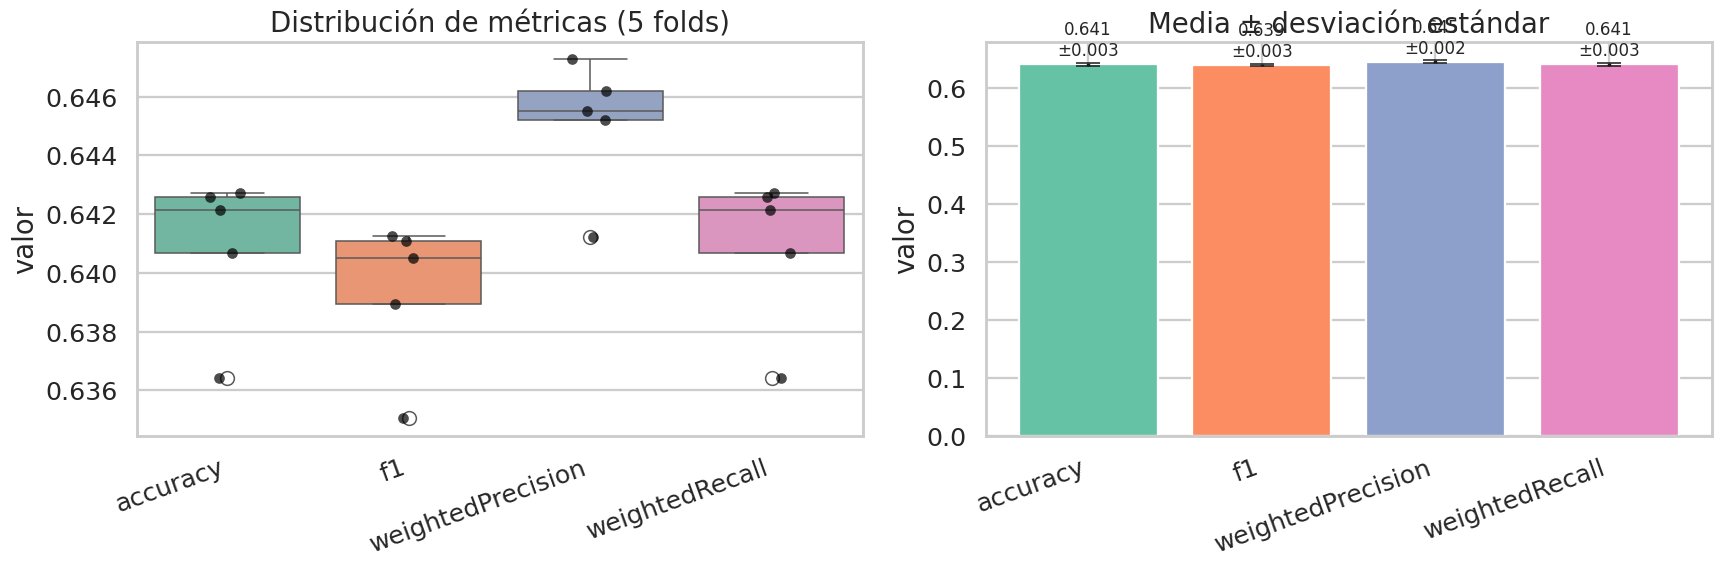

In [ ]:
box_metrics = ["accuracy", "f1", "weightedPrecision", "weightedRecall"]
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

melt = results_df.melt(id_vars="fold", value_vars=box_metrics, var_name="metric", value_name="value")
sns.boxplot(data=melt, x="metric", y="value", ax=axes[0], palette="Set2")
sns.stripplot(data=melt, x="metric", y="value", ax=axes[0], color="black", size=7, alpha=0.7)
axes[0].set_title(f"Distribución de métricas ({K} folds)")
axes[0].set_xlabel(""); axes[0].set_ylabel("valor")
plt.setp(axes[0].get_xticklabels(), rotation=20, ha="right")

means = results_df[box_metrics].mean()
stds  = results_df[box_metrics].std()
axes[1].bar(box_metrics, means.values, yerr=stds.values, capsize=8,
            color=sns.color_palette("Set2"))
for i, (m, s) in enumerate(zip(means.values, stds.values)):
    axes[1].text(i, m + s + 0.005, f"{m:.3f}\n±{s:.3f}", ha="center", va="bottom", fontsize=11)
axes[1].set_title("Media ± desviación estándar")
axes[1].set_ylabel("valor")
plt.setp(axes[1].get_xticklabels(), rotation=20, ha="right")
plt.tight_layout(); plt.show()


## 4.2 Gráficas de dispersión

(a) Dispersión de cada métrica por fold; (b) `F1 train` vs `F1 test` por fold (la cercanía
a la diagonal indica **ausencia de sobre-ajuste**); (c) dispersión de los datos en el
espacio de dos *features* clave, coloreada por la clase objetivo.


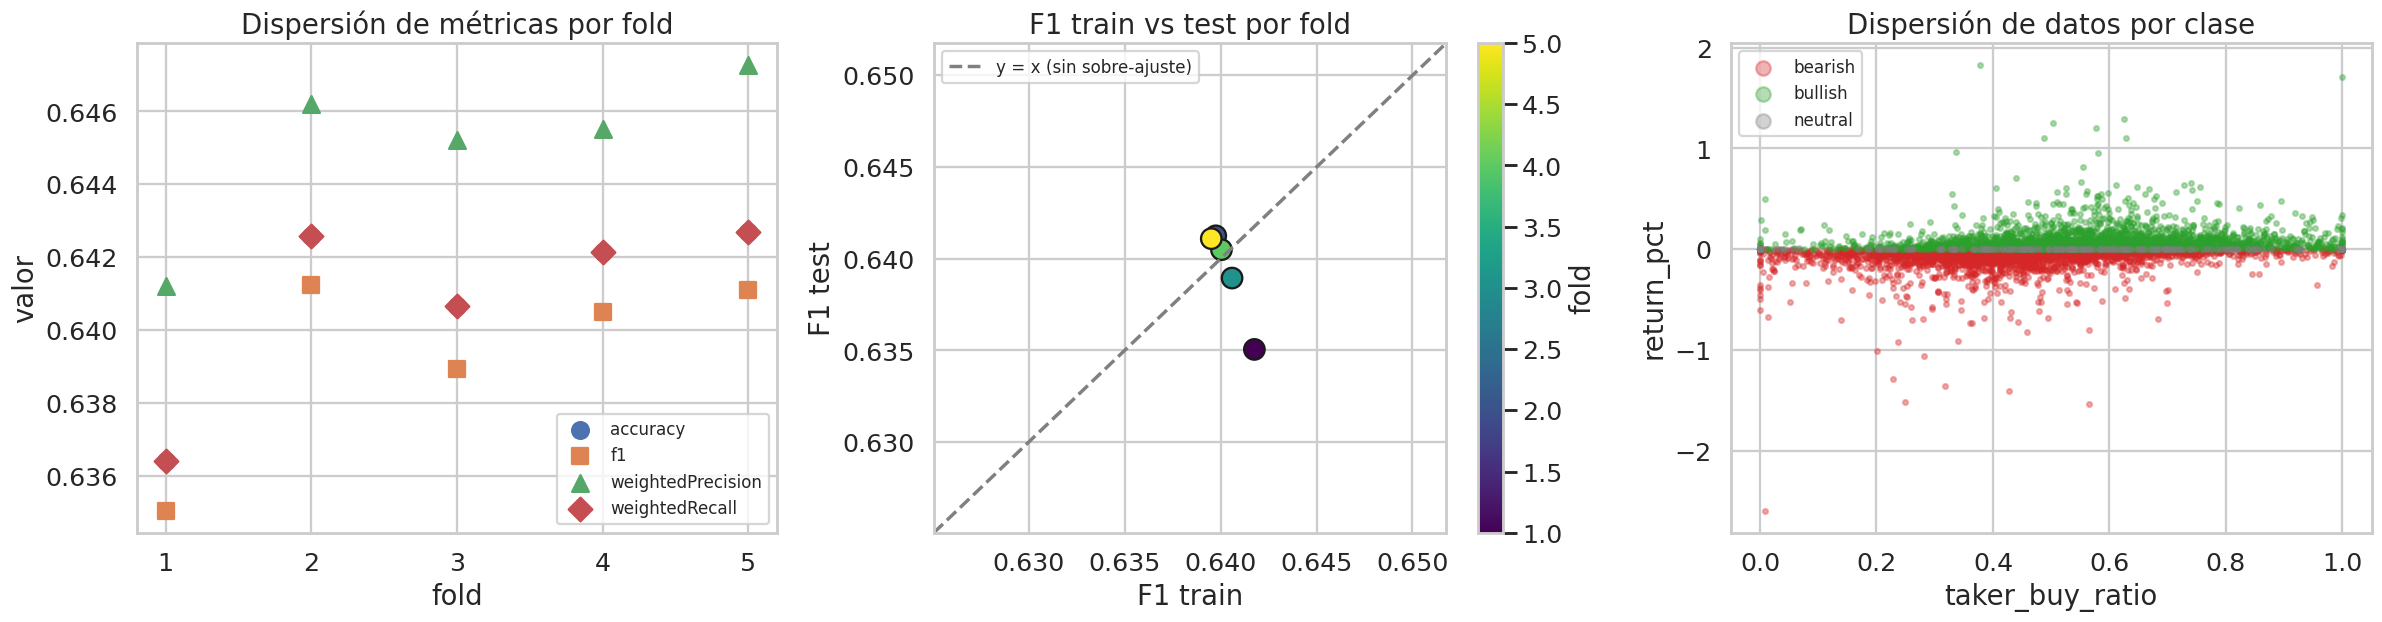

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# (a) per-fold metric dispersion
markers = {"accuracy": "o", "f1": "s", "weightedPrecision": "^", "weightedRecall": "D"}
for m in box_metrics:
    axes[0].scatter(results_df["fold"], results_df[m], s=120, marker=markers[m], label=m)
axes[0].set_xlabel("fold"); axes[0].set_ylabel("valor")
axes[0].set_title("Dispersión de métricas por fold")
axes[0].set_xticks(results_df["fold"]); axes[0].legend(fontsize=11)

# (b) train vs test F1 (overfitting)
sc = axes[1].scatter(results_df["f1_train"], results_df["f1"], s=180,
                     c=results_df["fold"], cmap="viridis", edgecolor="k")
lims = [min(results_df["f1_train"].min(), results_df["f1"].min()) - 0.01,
        max(results_df["f1_train"].max(), results_df["f1"].max()) + 0.01]
axes[1].plot(lims, lims, "--", color="gray", label="y = x (sin sobre-ajuste)")
axes[1].set_xlim(lims); axes[1].set_ylim(lims)
axes[1].set_xlabel("F1 train"); axes[1].set_ylabel("F1 test")
axes[1].set_title("F1 train vs test por fold"); axes[1].legend(fontsize=11)
plt.colorbar(sc, ax=axes[1], label="fold")

# (c) data scatter colored by target class
palette = {"bullish": "#2ca02c", "bearish": "#d62728", "neutral": "#7f7f7f"}
for cls, sub in feat_sample.groupby("market_direction"):
    axes[2].scatter(sub["taker_buy_ratio"], sub["return_pct"], s=10, alpha=0.35,
                    label=cls, color=palette.get(cls))
axes[2].set_xlabel("taker_buy_ratio"); axes[2].set_ylabel("return_pct")
axes[2].set_title("Dispersión de datos por clase")
axes[2].legend(markerscale=3, fontsize=11)
plt.tight_layout(); plt.show()


## 4.3 Mapas de calor

(a) **métrica × fold**: estabilidad de cada métrica a lo largo de los folds; (b) **matriz
de confusión** agregada de la validación cruzada (suma de los folds = predicción
*out-of-fold* sobre toda *M*), normalizada por fila (recall por clase); (c) **correlación**
entre las *features* numéricas.


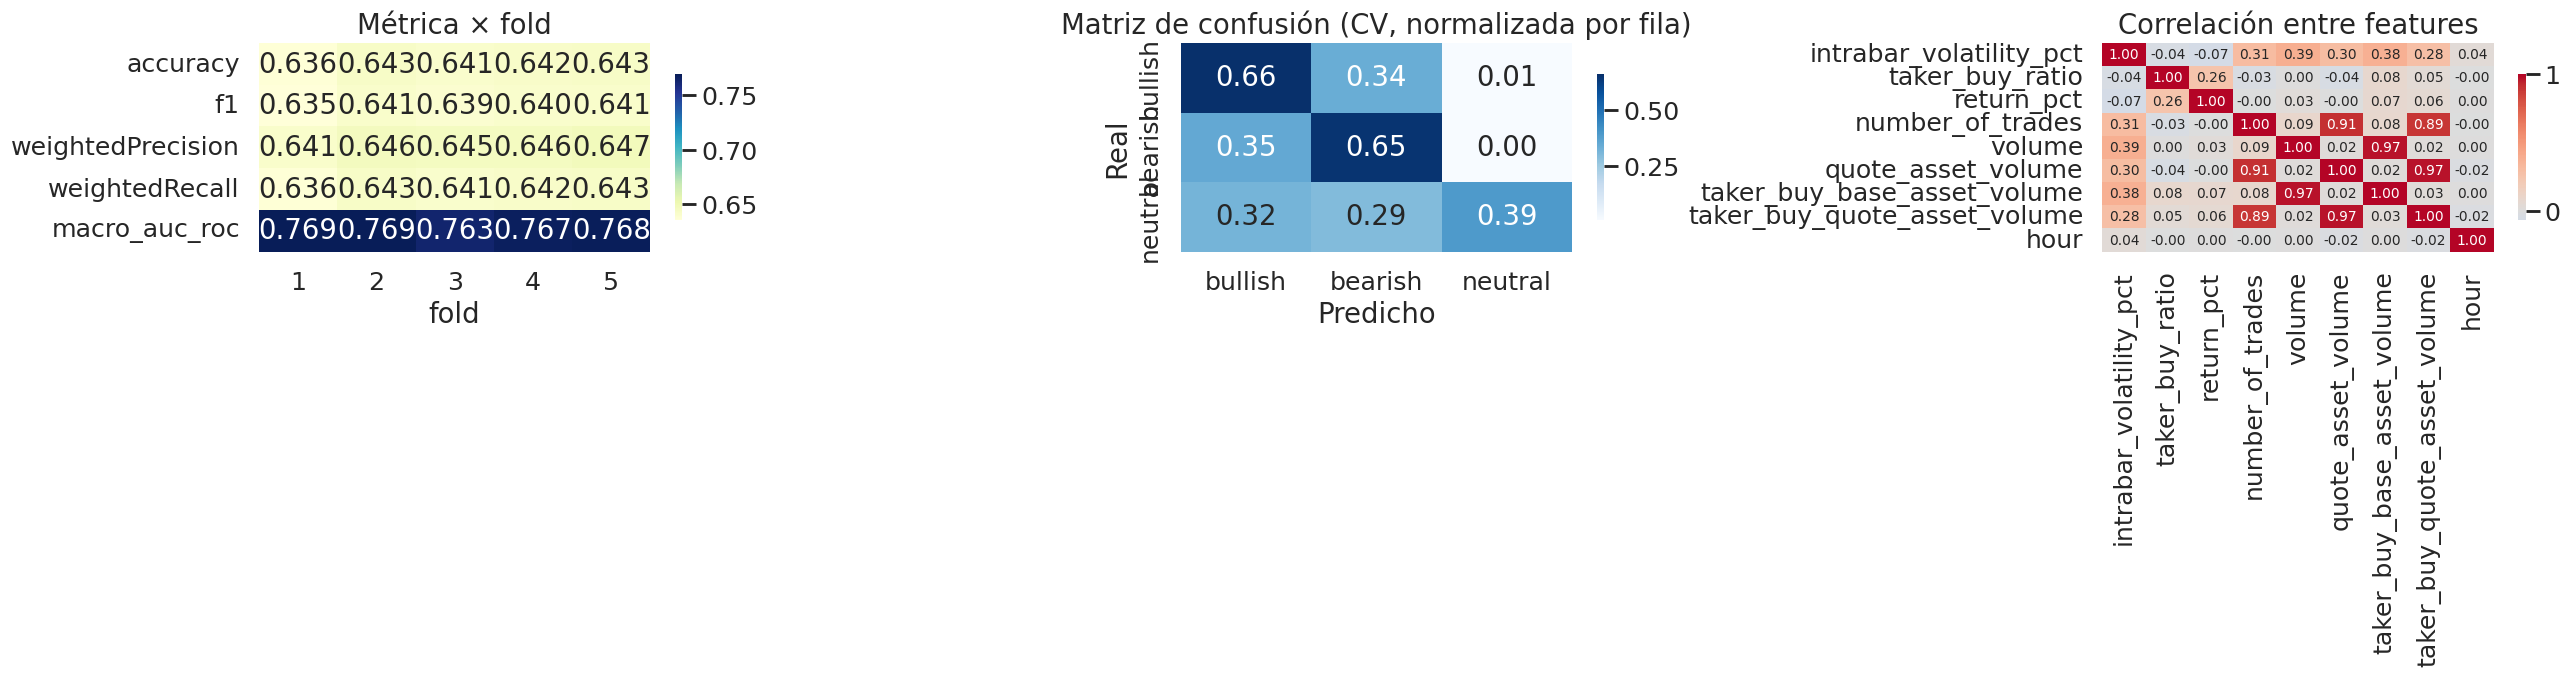

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(24, 6.5))

# (a) metric x fold
hm = results_df.set_index("fold")[["accuracy", "f1", "weightedPrecision",
                                   "weightedRecall", "macro_auc_roc"]].T
sns.heatmap(hm, annot=True, fmt=".3f", cmap="YlGnBu", ax=axes[0], cbar_kws={"shrink": 0.7})
axes[0].set_title("Métrica × fold"); axes[0].set_xlabel("fold"); axes[0].set_ylabel("")

# (b) cross-validated confusion matrix (row-normalized = recall)
cm_norm = cm_total / cm_total.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=labels_order, yticklabels=labels_order, ax=axes[1],
            cbar_kws={"shrink": 0.7})
axes[1].set_title("Matriz de confusión (CV, normalizada por fila)")
axes[1].set_xlabel("Predicho"); axes[1].set_ylabel("Real")

# (c) feature correlation
corr = feat_sample.drop(columns=["market_direction"]).corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[2],
            cbar_kws={"shrink": 0.7}, annot_kws={"size": 9})
axes[2].set_title("Correlación entre features")
plt.tight_layout(); plt.show()


## 4.4 Curvas ROC (one-vs-rest, media ± std across folds)

Para cada clase se promedia la curva ROC sobre los `k` folds (interpolada en una rejilla
común de FPR) y se muestra la **banda de ±1 desviación estándar**: además del AUC, revela
la **variabilidad** de la capacidad de *ranking* del modelo entre folds.


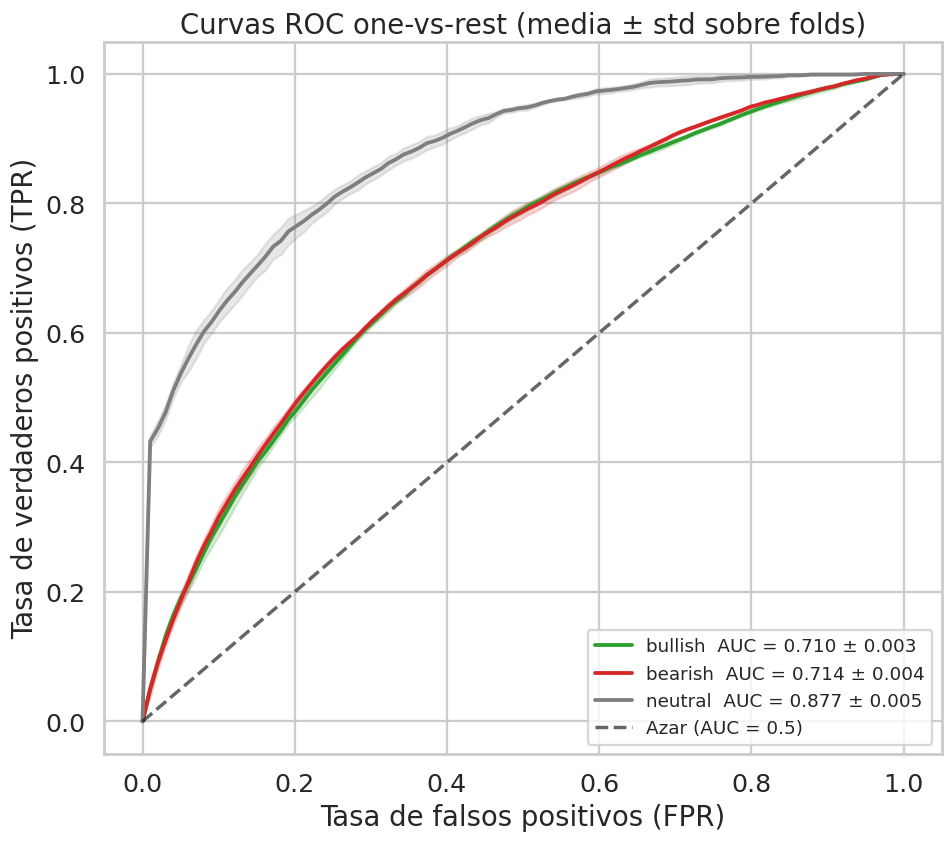

In [ ]:
mean_fpr = np.linspace(0, 1, 100)
fig, ax = plt.subplots(figsize=(9, 8))
colors = {"bullish": "#2ca02c", "bearish": "#d62728", "neutral": "#7f7f7f"}

for name in labels_order:
    tprs, aucs = [], []
    for j in range(1, K + 1):
        fpr, tpr, a = roc_store[j][name]
        it = np.interp(mean_fpr, fpr, tpr); it[0] = 0.0
        tprs.append(it); aucs.append(a)
    mtpr = np.mean(tprs, axis=0); mtpr[-1] = 1.0
    stpr = np.std(tprs, axis=0)
    c = colors.get(name, None)
    ax.plot(mean_fpr, mtpr, color=c, lw=2.5,
            label=f"{name}  AUC = {np.mean(aucs):.3f} ± {np.std(aucs):.3f}")
    ax.fill_between(mean_fpr, np.clip(mtpr - stpr, 0, 1), np.clip(mtpr + stpr, 0, 1),
                    color=c, alpha=0.18)

ax.plot([0, 1], [0, 1], "--", color="black", alpha=0.6, label="Azar (AUC = 0.5)")
ax.set_xlabel("Tasa de falsos positivos (FPR)")
ax.set_ylabel("Tasa de verdaderos positivos (TPR)")
ax.set_title("Curvas ROC one-vs-rest (media ± std sobre folds)")
ax.legend(loc="lower right", fontsize=12)
plt.tight_layout(); plt.show()


## 4.5 Evolución del entrenamiento (detección de sobre-ajuste) y variabilidad

(a) **F1 train vs test por fold**: una brecha pequeña y estable ⇒ sin sobre-ajuste.
(b) **Curva de complejidad** (F1 train/test vs `maxDepth`): a mayor profundidad el F1 de
*train* sube mientras el de *test* se estanca/cae ⇒ **sobre-ajuste**; valida la elección
`maxDepth = 5`. (c) **Coeficiente de variación** (`std/mean`) por métrica: variabilidad
relativa de los resultados. (d) **Recall por clase** across folds (la clase minoritaria
`neutral` es la crítica).


/tmp/ipykernel_9585/337813367.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=perclass_df, x="class", y="recallByLabel", ax=axes[1, 1], palette="Set3")


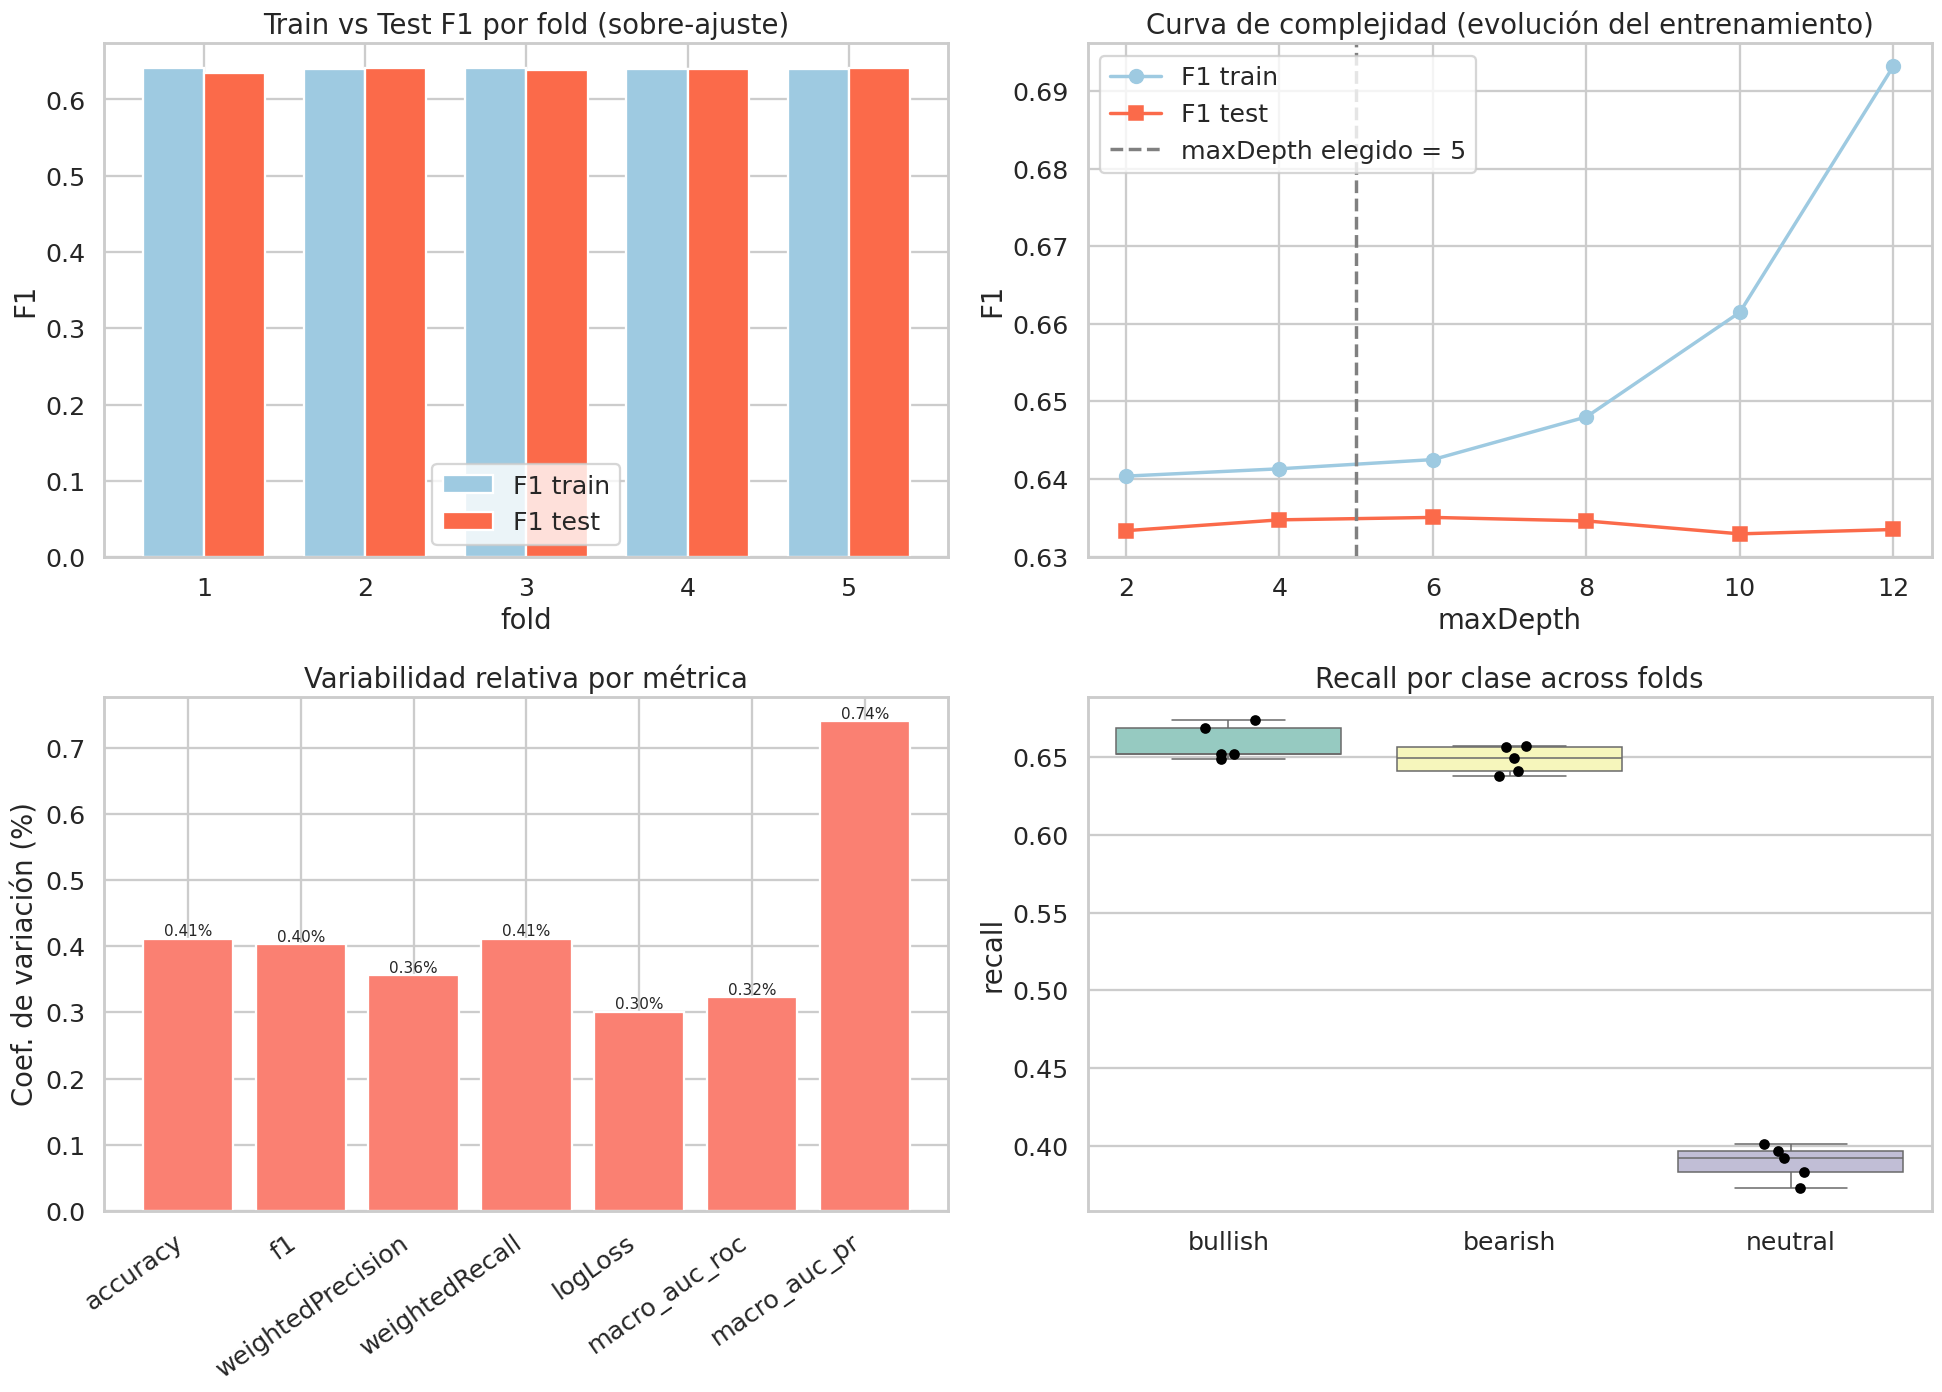

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 13))

# (a) train vs test F1 per fold
x = results_df["fold"].values; wbar = 0.38
axes[0, 0].bar(x - wbar/2, results_df["f1_train"], wbar, label="F1 train", color="#9ecae1")
axes[0, 0].bar(x + wbar/2, results_df["f1"],       wbar, label="F1 test",  color="#fb6a4a")
axes[0, 0].set_xticks(x); axes[0, 0].set_xlabel("fold"); axes[0, 0].set_ylabel("F1")
axes[0, 0].set_title("Train vs Test F1 por fold (sobre-ajuste)"); axes[0, 0].legend()

# (b) complexity curve
axes[0, 1].plot(lc_df["maxDepth"], lc_df["f1_train"], "o-", label="F1 train", color="#9ecae1")
axes[0, 1].plot(lc_df["maxDepth"], lc_df["f1_test"],  "s-", label="F1 test",  color="#fb6a4a")
axes[0, 1].axvline(BEST_MAX_DEPTH, ls="--", color="gray", label=f"maxDepth elegido = {BEST_MAX_DEPTH}")
axes[0, 1].set_xlabel("maxDepth"); axes[0, 1].set_ylabel("F1")
axes[0, 1].set_title("Curva de complejidad (evolución del entrenamiento)"); axes[0, 1].legend()

# (c) coefficient of variation per metric
cv = (results_df[metric_cols].std() / results_df[metric_cols].mean() * 100)
axes[1, 0].bar(cv.index, cv.values, color="salmon")
for i, v in enumerate(cv.values):
    axes[1, 0].text(i, v, f"{v:.2f}%", ha="center", va="bottom", fontsize=10)
axes[1, 0].set_ylabel("Coef. de variación (%)")
axes[1, 0].set_title("Variabilidad relativa por métrica")
plt.setp(axes[1, 0].get_xticklabels(), rotation=35, ha="right")

# (d) per-class recall across folds
sns.boxplot(data=perclass_df, x="class", y="recallByLabel", ax=axes[1, 1], palette="Set3")
sns.stripplot(data=perclass_df, x="class", y="recallByLabel", ax=axes[1, 1], color="black", size=7)
axes[1, 1].set_title("Recall por clase across folds")
axes[1, 1].set_xlabel(""); axes[1, 1].set_ylabel("recall")

plt.tight_layout(); plt.show()


## 4.6 Argumentación de los resultados

Esta subsección interpreta las figuras 4.1–4.5 con las **cifras obtenidas en la corrida**
(validación cruzada de 5 folds; cada métrica se evalúa sobre el pliegue *out-of-fold*).

**Resumen de la validación cruzada (conjunto de prueba):**

| Métrica | Media | Desv. est. | CV (%) | Mín. | Máx. |
|---|---|---|---|---|---|
| **F1 ponderado** | **0.6394** | 0.0026 | **0.40** | 0.6351 | 0.6413 |
| Accuracy | 0.6409 | 0.0026 | 0.41 | 0.6364 | 0.6427 |
| Precision ponderada | 0.6451 | 0.0023 | 0.36 | 0.6412 | 0.6473 |
| Recall ponderado | 0.6409 | 0.0026 | 0.41 | 0.6364 | 0.6427 |
| Log-loss | 0.7374 | 0.0022 | 0.30 | 0.7349 | 0.7407 |
| AUC-ROC (macro OvR) | 0.7672 | 0.0025 | 0.32 | 0.7629 | 0.7690 |
| AUC-PR (macro OvR) | 0.6258 | 0.0046 | 0.74 | 0.6209 | 0.6316 |

**Resultados por clase (matriz de confusión CV 4.3b y ROC OvR 4.4):**

| Clase | Recall | AUC-ROC |
|---|---|---|
| bullish | 0.66 | 0.710 |
| bearish | 0.65 | 0.714 |
| **neutral** | **0.39** | **0.877** |

- **Tendencia central (4.1).** El modelo se centra en un **F1 ponderado medio de 0.639**
  (accuracy 0.641, precision 0.645, recall 0.641), **~17 puntos por encima** del *baseline*
  de la clase mayoritaria (`bullish` ≈ 47 % ⇒ accuracy de azar ≈ 0.47). La microestructura
  de mercado **sí contiene señal** sobre la dirección de la vela.
- **Variabilidad (4.1, 4.3a, 4.5c).** La desviación estándar del F1 entre folds es
  **0.0026** (coeficiente de variación **0.40 %**), y *todas* las métricas tienen CV
  < 0.75 %. Una variabilidad tan baja indica resultados **muy estables y reproducibles**,
  no dependientes de la partición concreta de los datos.
- **Sobre-ajuste (4.2b, 4.5a, 4.5b).** La brecha media `F1 train − F1 test` es **≈ +0.001**
  (máximo 0.007; en 3 de los 5 folds es incluso **negativa**), por lo que los puntos caen
  sobre la diagonal. La **curva de complejidad** lo confirma: a partir de
  `maxDepth ≈ 6-8` el F1 de *train* se dispara (0.648 → **0.693** en profundidad 12)
  mientras el de *test* se estanca (~0.635), ampliando la brecha de 0.007 a **0.060** ⇒
  `maxDepth = 5` está **bien regularizado** y existe un **techo de predictibilidad** real
  (~0.64), no un problema de capacidad del modelo.
- **Capacidad de ranking (4.4).** El AUC-ROC medio *one-vs-rest* es **0.767** con una banda
  ±std muy estrecha (±0.0025) ⇒ separabilidad buena y **estable** entre folds. Destaca la
  clase `neutral`: pese a un **recall bajo (0.39)** en la matriz de confusión, tiene el
  **AUC más alto (0.877)** → el modelo la *ordena* muy bien, aunque el umbral de decisión
  por defecto no la *clasifique* bien.
- **Errores (4.3b).** El error dominante es la confusión **bullish ↔ bearish** (≈ 34 % de
  las velas *bullish* se predicen *bearish* y ≈ 35 % de las *bearish* como *bullish*),
  esperable porque ambas dependen de un balance fino de presión compradora/vendedora.
- **Correlación de features (4.3c).** Las correlaciones fuertes se limitan al bloque de
  variables de volumen (`volume`, `quote_asset_volume`, volúmenes *taker*), redundancia
  esperable y ya controlada; el resto de predictores aporta información complementaria.


# Discusión y conclusiones

## 5.1 Significancia de los resultados respecto a la tarea de aprendizaje

La tarea planteada en el proyecto es **predecir la dirección de la vela**
(`market_direction` ∈ {bullish, bearish, neutral}) **a partir únicamente de su
microestructura de mercado** (volumen, nº de trades, presión compradora, volatilidad,
sesión y símbolo), evitando deliberadamente las variables de precio de las que se deriva la
etiqueta (sin fuga de información).

- El **F1 ponderado medio de 0.639** (accuracy 0.641) supera en **≈ 17 puntos** al
  *baseline* de azar informado (~0.47, clase mayoritaria *bullish*). El resultado es
  **estadísticamente significativo**: el modelo aprende patrones reales. No obstante,
  existe un **techo de predictibilidad ≈ 0.64**, confirmado por la curva de complejidad
  (ni árboles de profundidad 12 mejoran el F1 de *test*): con sólo información intra-vela la
  dirección no puede predecirse mejor.
- El **AUC-ROC medio de 0.767** confirma separabilidad por encima del azar de forma
  consistente en las tres clases (neutral 0.877, bearish 0.714, bullish 0.710).

## 5.2 Variabilidad de los experimentos

La validación cruzada con `k = 5` —con **cada fold demostrado representativo de *P***
(tamaño ≈ 14,060 instancias, **1.47× el mínimo de Cochran** `n_min = 9,593`, y desviación
máxima de proporciones por estrato de **≤ 0.009 pp** respecto a la población)— arroja:

- **Desviación estándar del F1 = 0.0026** (CV = **0.40 %**) y bandas ±std muy estrechas en
  las curvas ROC (±0.0025) ⇒ los resultados son **estables**: la calidad reportada **no es
  un artefacto** de una partición afortunada, sino una propiedad del modelo sobre la
  población. El rango completo de F1 entre folds (0.6351–0.6413) es de apenas 0.006.
- La baja variabilidad, unida a la **brecha train–test ≈ +0.001** (prácticamente nula y
  negativa en 3 folds), permite **confiar en que el desempeño generaliza** a datos no vistos
  de la misma población.

## 5.3 Análisis crítico y áreas de oportunidad

- **Clase `neutral` sub-detectada.** Recall ≈ **0.39** pero AUC ≈ **0.877**: el modelo la
  *separa* muy bien pero el umbral por defecto la *predice* poco (es la clase minoritaria,
  ~5 %). Procede **ajustar el umbral de decisión**, aplicar **pesos de clase** o
  **sobre-muestreo** para convertir esa capacidad de *ranking* en aciertos efectivos.
- **Techo de predictibilidad (~0.64).** Para superarlo habría que **enriquecer las
  *features*** (variables rezagadas/temporales que aporten memoria del mercado, datos de
  *order-book*, indicadores técnicos), siempre evitando fuga de información.
- **Confusión bullish ↔ bearish.** Es el error dominante; un esquema jerárquico
  (primero neutral vs. no-neutral, luego dirección) podría atacar específicamente esta
  frontera fina.
- **Costo vs. resolución.** `k = 5` fue el equilibrio adecuado entre representatividad de
  los folds y costo de cómputo en Big Data: 5 entrenamientos de ~150-210 s cada uno
  (~13 min en total). Un `k` mayor habría encarecido la experimentación **sin** aportar
  representatividad —los folds caerían por debajo del mínimo de Cochran (`k = 10` ⇒ folds de
  7,030 < 9,593)—.

## 5.4 Conclusión

Se definió y **argumentó cuantitativamente** un proceso de validación cruzada (`k = 5`,
elegido porque cada fold supera el mínimo de representatividad de Cochran con holgura
—1.47×— mientras `k ≥ 8` lo violaría), se construyeron los folds mediante **muestreo
estratificado** (heredado de la Actividad 3) preservando la distribución de las 27
particiones con desviación ≤ 0.009 pp, y se entrenó el **mejor modelo de la Actividad 4**
(`RandomForestClassifier`, 100 árboles, profundidad 5) midiéndolo con su **métrica
principal (F1 ponderado = 0.639 ± 0.003)** y la batería complementaria. La **visualización**
(dispersión, tendencia central, mapas de calor y curvas ROC) hace evidente que los
resultados son **significativos** (F1 ~17 pts sobre el azar; AUC-ROC 0.767), **estables**
(CV de todas las métricas < 0.75 %) y **sin sobre-ajuste** (brecha train–test ≈ 0.001). El
valor metodológico de la actividad reside en que **visualizar la variabilidad** —y no una
sola cifra— es lo que permite **confiar** en que el modelo generaliza sobre grandes
volúmenes de datos.
